In [1]:
import time
import numpy as np
import xarray as xr
import ast
from datetime import datetime, timedelta
from workers.processing import find_centroid, find_stars
from workers.compression import crop_centre, crop_sidelobes_old, crop_sidelobes
import matplotlib.pyplot as plt
from PIL import Image

In [22]:
# raw_filename = "/home/toliman-dev/toliman/imageservice/imageservice/images/raw/frame_642282821296.npy"
raw_filename = "/home/toliman-dev/toliman/imageservice/imageservice/images/simulated/toliman_image_00.npy"
raw_image = np.load(raw_filename)

# raw_image = np.asarray(Image.open("toliman_image_0.png"))
# raw_image = raw_image[:,912:4560]
# np.save("images/simulated/toliman_image_0.npy", raw_image)

In [23]:
raw_image.dtype.name

'uint16'

In [24]:
last_frame_time = datetime.now()

In [29]:
now = datetime.now()
elapsed = now - last_frame_time

In [37]:
elapsed < interval

False

In [34]:
interval = timedelta(microseconds=1e5)

In [38]:
timedelta(seconds=0.1)

datetime.timedelta(microseconds=100000)

In [40]:
time.time()

1744087376.2414644

In [25]:
metadata_file = raw_filename.strip(".npy")+".txt"

with open(metadata_file, "r") as file:
    for line in file:
        header = ast.literal_eval(line.strip())

In [26]:
%%time
centroid_data = find_centroid(raw_image)
core = crop_centre(raw_image, centroid_data["x"], centroid_data["y"])
star_poss = find_stars(core)
x_poss = star_poss['xs'] + np.rint(centroid_data['x']).astype(int) - core.shape[1]//2
y_poss = star_poss['ys'] + np.rint(centroid_data['y']).astype(int) - core.shape[0]//2

CPU times: user 128 ms, sys: 54.4 ms, total: 183 ms
Wall time: 185 ms


In [27]:
%%time
sidelobes_old = crop_sidelobes_old(raw_image, x_poss, y_poss)

CPU times: user 1.16 s, sys: 495 ms, total: 1.65 s
Wall time: 1.68 s


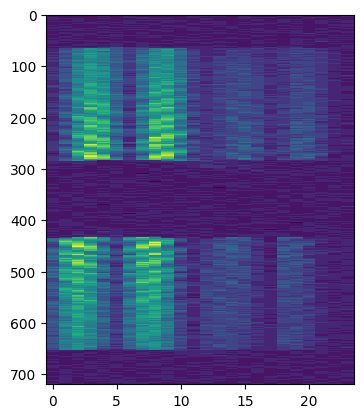

In [28]:
plt.imshow(sidelobes_old, aspect=0.04, interpolation='nearest');

In [29]:
%%time
sidelobes_new = crop_sidelobes(raw_image, x_poss, y_poss, centroid_data)

CPU times: user 140 ms, sys: 114 ms, total: 254 ms
Wall time: 262 ms


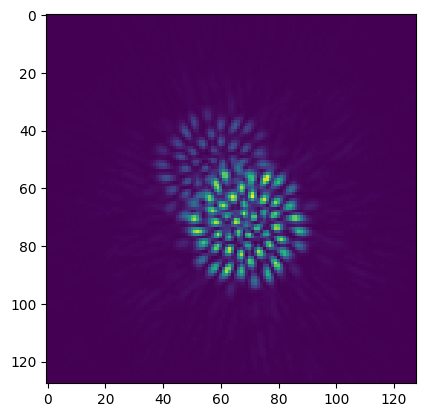

In [30]:
plt.imshow(core, aspect=1, interpolation='nearest');

In [31]:
header

{'SEQNUM': 0,
 'CAMTIME': 22540362524944,
 'COMTIME': '2025-04-08 15:55:43.682742',
 'EXPOSURE': 46.0,
 'PXLFMT': 'Mono16',
 'XOFF': 912,
 'YOFF': 0,
 'XPAD': 0,
 'YPAD': 0}

In [32]:
centroid_data

{'x': np.float64(1823.500644814733),
 'y': np.float64(1823.6904068275014),
 't': '2025-12-09 16:26:46.325751'}

In [33]:
x_poss

array([1829, 1819])

In [34]:
y_poss

array([1833, 1815])

In [24]:
sort1 = np.sort(sidelobes_old,axis=None)
sort2 = np.sort(sidelobes_new,axis=None)

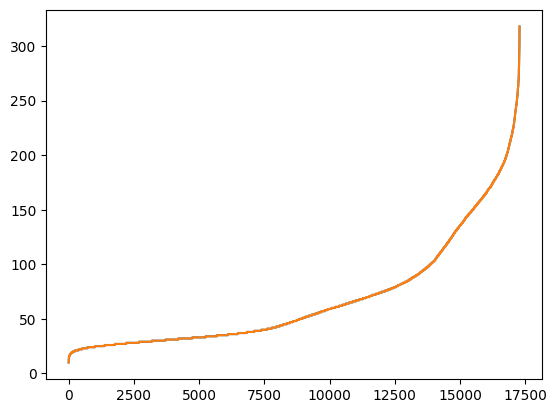

In [25]:
plt.plot(sort1)
plt.plot(sort2)

In [10]:
image = raw_image

## Generate old mask

In [11]:
y, x = np.indices(image.shape)

In [12]:
x_pos = x_poss[0]
y_pos = y_poss[0]

y = y-y_pos
x = x-x_pos

In [13]:
angle_degrees = 45
angles_radians = [np.deg2rad(angle_degrees), np.deg2rad(angle_degrees+90)]

angle = angles_radians[0]

In [14]:
SIDELOBE_OFFSET = 1625

In [15]:
sidelobe_x = np.abs(SIDELOBE_OFFSET * np.cos(angle))
sidelobe_y = np.abs(SIDELOBE_OFFSET * np.sin(angle))

In [17]:
width = 6
length=360

In [18]:
mask = (np.abs(x - y / np.tan(angle)) <= width/2) & (np.abs(np.abs(y)-sidelobe_y) <= length/2)

In [21]:
np.sum(mask)

np.int64(4320)

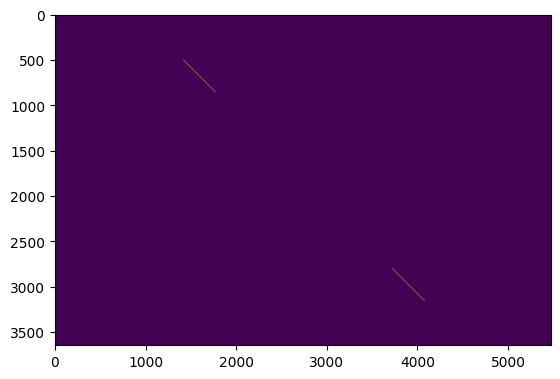

In [23]:
plt.imshow(mask);

## Generate new mask

In [28]:
def crop_areas(image, x_poss, y_poss, size = (480, 360)):
    output = []

    for x_pos, y_pos in zip(x_poss, y_poss):
        # Round positions
        x_pos = round(x_pos)
        y_pos = round(y_pos)
    
        # Calculate dimensions of the cutout
        half_size_x = size[1] // 2
        half_size_y = size[0] // 2
        start_x = max(x_pos - half_size_x, 0)
        start_y = max(y_pos - half_size_y, 0)
        end_x = min(x_pos + half_size_x + (size[1] % 2), image.shape[1])
        end_y = min(y_pos + half_size_y + (size[0] % 2), image.shape[0])
    
        # Extract cutout
        output.append(image[start_y:end_y, start_x:end_x])

    return np.asarray(output)

In [24]:
angles_radians = np.array([np.deg2rad(angle_degrees), np.deg2rad(angle_degrees+90)])

In [25]:
sidelobes_x = (SIDELOBE_OFFSET * np.cos(angles_radians)).astype(int)
sidelobes_y = (SIDELOBE_OFFSET * np.sin(angles_radians)).astype(int)

In [26]:
sidelobes_x = np.concatenate((sidelobes_x, - sidelobes_x))
sidelobes_y = np.concatenate((sidelobes_y, - sidelobes_y))
angles_radians = np.concatenate((angles_radians, angles_radians))

In [27]:
y, x = np.indices(image.shape)
yy = (y - np.broadcast_to(y_poss, (*image.shape, 2)).transpose((2,0,1))).transpose((1,2,0))
xx = (x - np.broadcast_to(x_poss, (*image.shape, 2)).transpose((2,0,1))).transpose((1,2,0))

In [29]:
crop_im = crop_areas(image, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_x = crop_areas(xx, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_y = crop_areas(yy, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)

In [30]:
crop_im = np.transpose(crop_im, axes=(1,2,0))
crop_x = np.transpose(crop_x, axes=(1,2,3,0))
crop_y = np.transpose(crop_y, axes=(1,2,3,0))

In [31]:
tan = np.tan(angles_radians)
cot = 1/tan

In [32]:
mask = np.abs(crop_x - crop_y*cot) <= width/2

In [33]:
mask.shape

(480, 360, 2, 4)

In [37]:
np.sum(mask[:,:,0,0])

np.int64(2160)

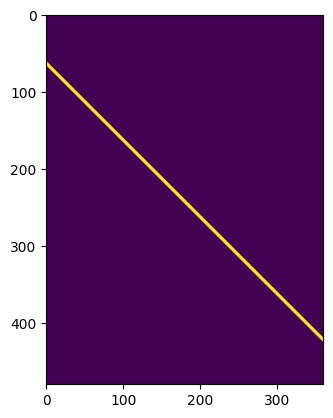

In [38]:
plt.imshow(mask[:,:,0,0]);

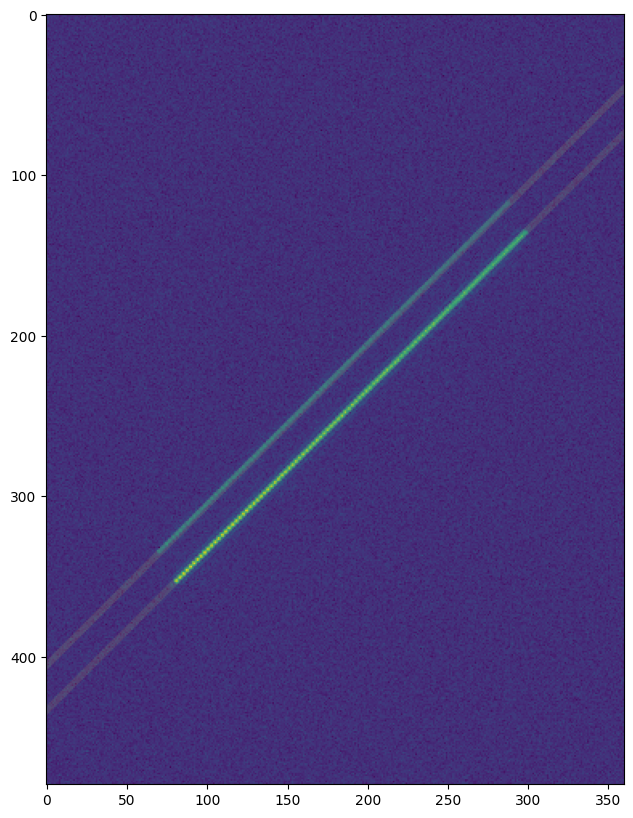

In [48]:
plt.figure(figsize = (10,10))
plt.imshow(crop_im[:,:,3]**0.5)
plt.imshow(mask[:,:,0,3], alpha=0.1);
plt.imshow(mask[:,:,1,3], alpha=0.1);

In [49]:
res = crop_im[:,:,0][mask[:,:,0,0]]

In [60]:
output = res.reshape(360,6);

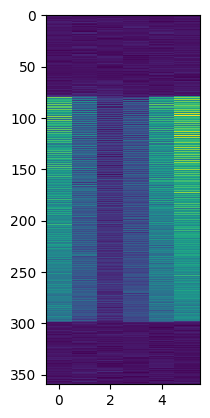

In [61]:
plt.imshow(output, aspect=0.04, interpolation='nearest');

In [66]:
res = crop_im[mask[:,:,0,0]]

In [67]:
res.shape

(2160, 4)

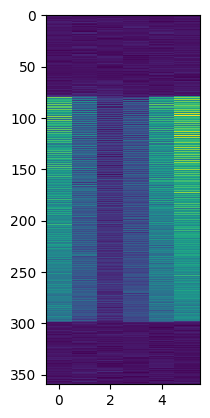

In [103]:
res = crop_im[mask[:,:,0,0]]
output = res[:,0].reshape(360,6)
plt.imshow(output, aspect=0.04, interpolation='nearest');

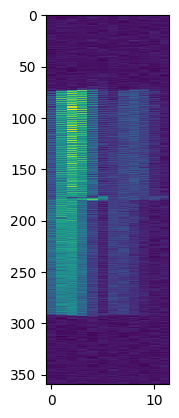

In [98]:
plt.imshow(sidelobes[np.arange(1,720,2),:][:,np.arange(1,24,2)], aspect=0.1, interpolation='nearest')

In [109]:
crop_im.shape

(480, 360, 4)

In [112]:
crop_im2 = np.tile(crop_im, (2,1,1,1)).transpose((1,2,0,3))

In [113]:
res = crop_im2[mask]

In [116]:
output = res.reshape(720,24);

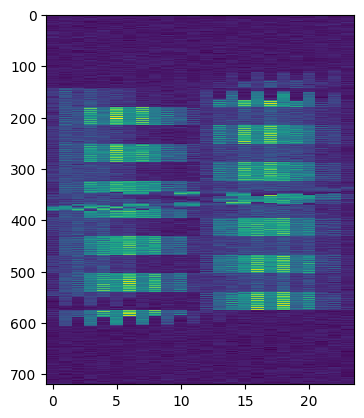

In [117]:
plt.imshow(output, aspect=0.04, interpolation='nearest');

In [119]:
crop_im2.shape

(480, 360, 2, 4)

In [120]:
mask.shape

(480, 360, 2, 4)

In [123]:
crop_im2[:,:,0,0] = 0
crop_im2[:,:,0,1] = 1
crop_im2[:,:,0,2] = 2
crop_im2[:,:,0,3] = 3
crop_im2[:,:,1,0] = 8
crop_im2[:,:,1,1] = 9
crop_im2[:,:,1,2] = 10
crop_im2[:,:,1,3] = 11

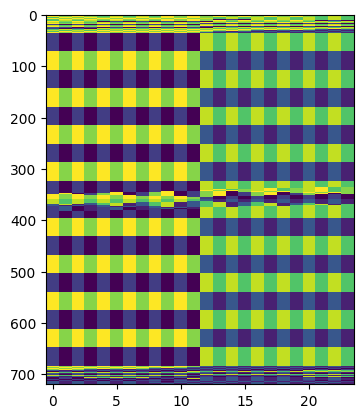

In [131]:
plt.imshow(crop_im2[mask].reshape(720,24), interpolation='nearest', aspect=0.04);

In [132]:
decode_array = crop_im2[mask].reshape(720,24)

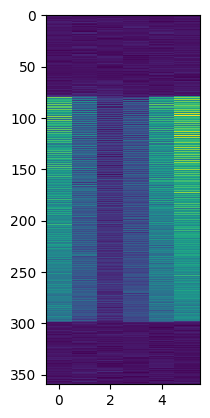

In [147]:
plt.imshow(output[decode_array == 0].reshape(360,6), aspect=0.04, interpolation='nearest');

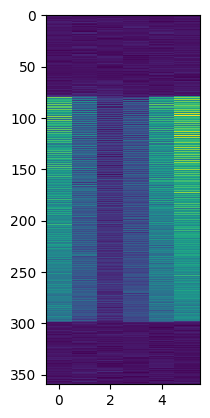

In [148]:
plt.imshow(crop_im[mask[:,:,0,0]][:,0].reshape(360,6), aspect=0.04, interpolation='nearest');

In [154]:
mask[:,:,0,0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(480, 360))

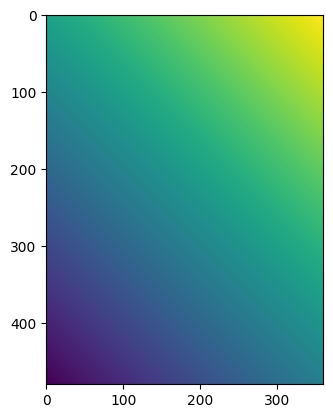

In [170]:
y, x = np.indices((480,360))
plt.imshow(x-y, interpolation='nearest');
i = x-y

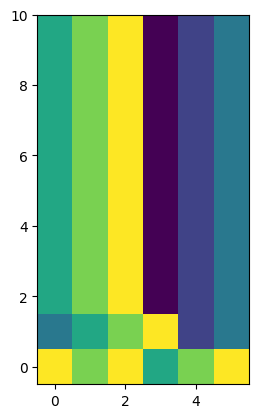

In [200]:
plt.imshow(i[mask[:,:,0,0]].reshape(360,6), aspect=1, interpolation='nearest')
plt.ylim(-0.5,10);


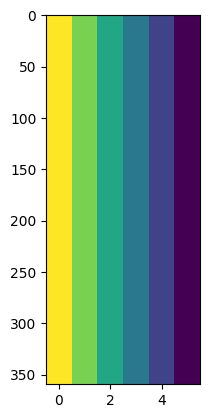

In [205]:
plt.imshow(i.T[mask[:,:,0,0].T].reshape(360,6),aspect=0.04, interpolation='nearest');

(350.0, 360.0)

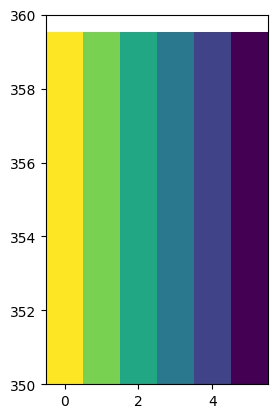

In [207]:
plt.imshow(i.T[mask[:,:,0,0].T].reshape(360,6),aspect=1, interpolation='nearest');
plt.ylim(350,360)

In [226]:
crop_im2 = np.tile(crop_im, (2,1,1,1)).transpose((1,2,0,3))

crop_i = crop_im2.copy()
crop_i[:,:,0,0] = 0
crop_i[:,:,0,1] = 1
crop_i[:,:,0,2] = 2
crop_i[:,:,0,3] = 3
crop_i[:,:,1,0] = 8
crop_i[:,:,1,1] = 9
crop_i[:,:,1,2] = 10
crop_i[:,:,1,3] = 11

In [241]:
np.tile(crop_im, (2,1,1,1)).transpose((3,0,2,1)).shape

(4, 2, 360, 480)

In [238]:
crop_im2.shape

(480, 360, 2, 4)

In [240]:
crop_im2.T.shape

(4, 2, 360, 480)

In [229]:
res = crop_im2.T[mask.T]
res_i = crop_i.T[mask.T]

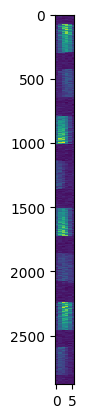

In [233]:
plt.imshow(res.reshape(360*8,6),aspect=0.04, interpolation='nearest')

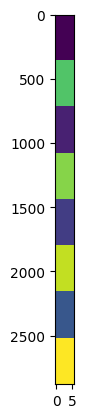

In [234]:
plt.imshow(res_i.reshape(360*8,6),aspect=0.04, interpolation='nearest')

In [74]:
sidelobes.shape

(720, 24)

In [10]:
angle_degrees = 45
width = 6
length = 360
SIDELOBE_OFFSET = 1625
image = raw_image

In [11]:
output = []
angles_radians = np.array([np.deg2rad(angle_degrees), np.deg2rad(angle_degrees+90)])

sidelobes_x = (SIDELOBE_OFFSET * np.cos(angles_radians)).astype(int)
sidelobes_y = (SIDELOBE_OFFSET * np.sin(angles_radians)).astype(int)

sidelobes_x = np.concatenate((sidelobes_x, - sidelobes_x))
sidelobes_y = np.concatenate((sidelobes_y, - sidelobes_y))
angles_radians = np.concatenate((angles_radians, angles_radians))


In [23]:
y, x = np.indices(image.shape)
yy = (y - np.broadcast_to(y_poss, (*image.shape, 2)).transpose((2,0,1))).transpose((1,2,0))
xx = (x - np.broadcast_to(x_poss, (*image.shape, 2)).transpose((2,0,1))).transpose((1,2,0))

In [19]:
(y - np.broadcast_to(y_poss, (*image.shape, 2)).transpose((2,0,1)))

array([[[-1833, -1833, -1833, ..., -1833, -1833, -1833],
        [-1832, -1832, -1832, ..., -1832, -1832, -1832],
        [-1831, -1831, -1831, ..., -1831, -1831, -1831],
        ...,
        [ 1812,  1812,  1812, ...,  1812,  1812,  1812],
        [ 1813,  1813,  1813, ...,  1813,  1813,  1813],
        [ 1814,  1814,  1814, ...,  1814,  1814,  1814]],

       [[-1815, -1815, -1815, ..., -1815, -1815, -1815],
        [-1814, -1814, -1814, ..., -1814, -1814, -1814],
        [-1813, -1813, -1813, ..., -1813, -1813, -1813],
        ...,
        [ 1830,  1830,  1830, ...,  1830,  1830,  1830],
        [ 1831,  1831,  1831, ...,  1831,  1831,  1831],
        [ 1832,  1832,  1832, ...,  1832,  1832,  1832]]],
      shape=(2, 3648, 5472))

In [24]:
crop_im = crop_areas(image, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_x = crop_areas(xx, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_y = crop_areas(yy, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)

In [25]:
crop_im = np.transpose(crop_im, axes=(1,2,0))
crop_x = np.transpose(crop_x, axes=(1,2,3,0))
crop_y = np.transpose(crop_y, axes=(1,2,3,0))

In [26]:
tan = np.tan(angles_radians)
cot = 1/tan

In [27]:
mask = np.abs(crop_x[:,:,:,:] - crop_y[:,:,:,:]*cot) <= width/2

In [28]:
mask.shape

(480, 360, 2, 4)

In [29]:
crop_im.shape

(480, 360, 4)

In [30]:
for a in range(2):
    print(a)

0
1


In [31]:
for a in range(2):
    output.append(crop_im[mask[:,:,a,:]].reshape(length*2,width*2))

In [32]:
result = np.block([a for a in output])

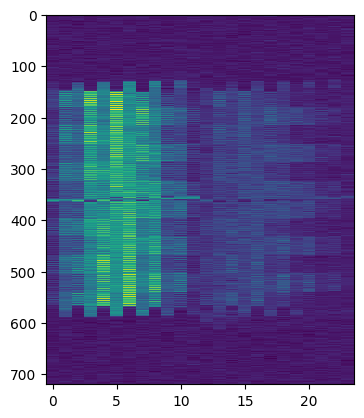

In [33]:
plt.imshow(result, aspect=0.04, interpolation='nearest');

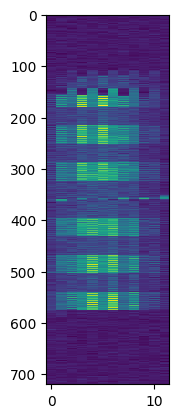

In [38]:
plt.imshow(crop_im[mask[:,:,0,:]].reshape(720,12),aspect=0.05,interpolation='nearest');

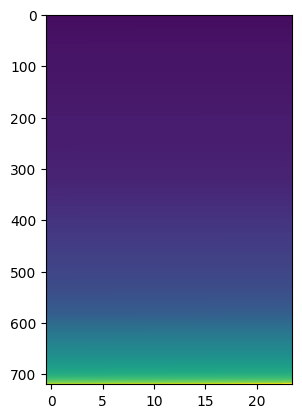

In [60]:
plt.imshow(np.sort(result, axis=None).reshape(720,24),aspect=0.05, interpolation='nearest')

In [47]:
sort1 = np.sort(sidelobes,axis=None)
sort2 = np.sort(result,axis=None)

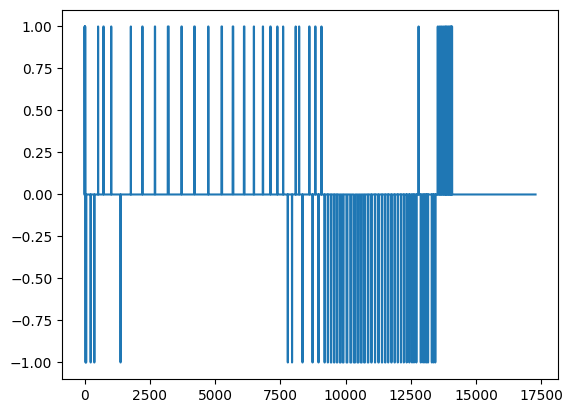

In [59]:
plt.plot(sort1.astype('float')-sort2.astype('float'))

In [56]:
sort2.astype('float')

array([ 10.,  12.,  13., ..., 306., 307., 318.], shape=(17280,))

In [52]:
float(sort1)-float(sort2)

TypeError: only length-1 arrays can be converted to Python scalars

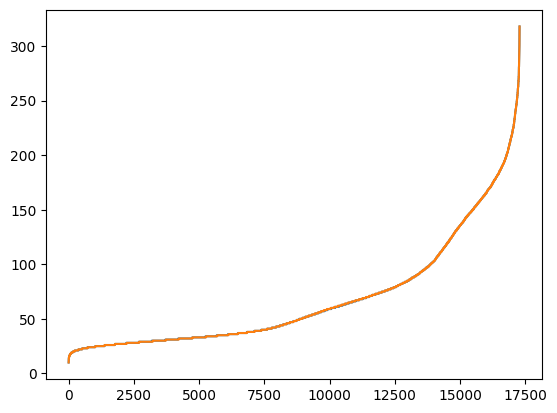

In [50]:
plt.plot(sort1)
plt.plot(sort2)

In [49]:
np.sum(sort2-sort1)

np.uint64(20709701)

In [133]:
mask.shape

(480, 360, 2, 4)

In [134]:
np.sum(mask)

np.int64(17280)

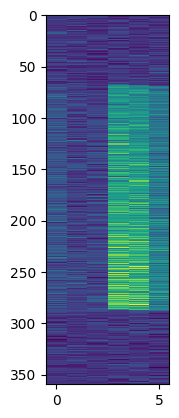

In [165]:
plt.imshow(crop_im[:,:,3][mask[:,:,1,3]].reshape(360,6),aspect=0.05, interpolation='nearest');

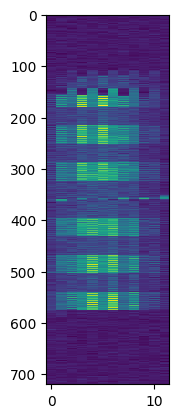

In [168]:
plt.imshow(crop_im[:,:,:][mask[:,:,0,:]].reshape(720,12),aspect=0.05, interpolation='nearest');

(720.0, 360.0)

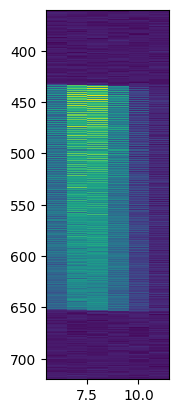

In [160]:
plt.imshow(sidelobes, aspect = 0.05, interpolation='nearest')
plt.xlim(5.5,11.5)
plt.ylim(720,360)

In [115]:
plt.imshow(crop_im[mask[:,:,0,0]].reshape(360,6), aspect=0.01, interpolation='nearest')

ValueError: cannot reshape array of size 8640 into shape (360,6)

In [ ]:
output = np.tile(crop_im, (2, 1, 1)).T[mask].reshape(346*2,6)

In [98]:
crop_x.shape

(480, 360, 2, 4)

In [75]:
crop_im.shape

(480, 360, 4)

In [78]:
crop_im[mask[:,:,0,:]]

array([27, 31, 40, ..., 32, 25, 26], shape=(8640,), dtype=uint16)

In [68]:
np.sum(mask)/2/4/6

np.float64(360.0)

In [117]:
crop_im.shape

(480, 360, 4)

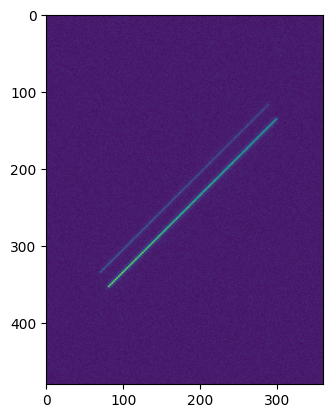

In [126]:
plt.imshow(crop_im[:,:,3]);

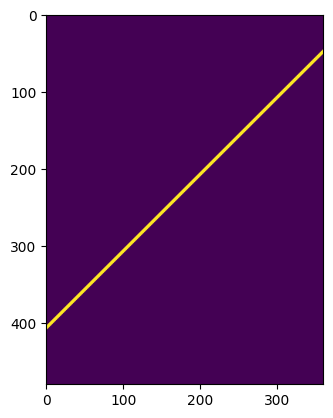

In [127]:
plt.imshow(mask[:,:,1,3]);

In [47]:
crop_x[:,:,0,0] - crop_y[:,:,0,0]*cot

array([[ -56.,  -57.,  -58., ..., -413., -414., -415.],
       [ -55.,  -56.,  -57., ..., -412., -413., -414.],
       [ -54.,  -55.,  -56., ..., -411., -412., -413.],
       ...,
       [ 421.,  420.,  419., ...,   64.,   63.,   62.],
       [ 422.,  421.,  420., ...,   65.,   64.,   63.],
       [ 423.,  422.,  421., ...,   66.,   65.,   64.]], shape=(480, 360))

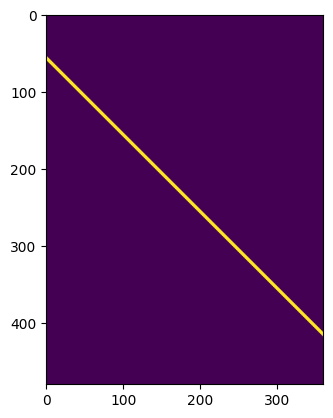

In [49]:
plt.imshow(np.abs(crop_x[:,:,0,0] - crop_y[:,:,0,0]*cot) <= width/2);

In [34]:
172800/width

28800.0

In [19]:
crop_x.T.shape

(2, 360, 480, 4)

In [284]:
for sx, sy in zip(sidelobes_x, sidelobes_y):
    crop_im = crop_centre(image, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)
    crop_x = crop_centre(xx, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)
    crop_y = crop_centre(yy, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)


In [288]:
crop_im = crop_areas(image, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_x = crop_areas(xx, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_y = crop_areas(xx, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)

In [291]:
np.asarray(crop_x).shape

(4, 480, 360, 2)

In [302]:
np.sum(np.abs(np.asarray(crop_y) - np.asarray(crop_x)*tan) <= width/2)

np.int64(0)

In [205]:
%%time
output = []

y, x = np.indices(image.shape)
yy = (y - np.broadcast_to(y_poss, (*image.shape, 2)).T).T
xx = (x - np.broadcast_to(x_poss, (*image.shape, 2)).T).T

tan = np.tan(angles_radians[1])
cot = 1/tan

for sx, sy in zip(sidelobes_x, sidelobes_y):
    crop_im = crop_centre(image, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)
    crop_x = crop_centre(xx, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)
    crop_y = crop_centre(yy, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)

    mask = np.abs(crop_x - crop_y*cot) <= width/2

CPU times: user 111 ms, sys: 85.1 ms, total: 196 ms
Wall time: 197 ms


In [280]:
np.asarray(crop_im)

array([[[32, 24, 39, ..., 29, 30, 33],
        [28, 30, 31, ..., 41, 33, 24],
        [22, 31, 36, ..., 31, 34, 32],
        ...,
        [33, 23, 28, ..., 30, 25, 39],
        [29, 37, 32, ..., 38, 36, 26],
        [40, 29, 35, ..., 28, 29, 26]],

       [[41, 30, 26, ..., 31, 34, 28],
        [33, 33, 34, ..., 29, 32, 29],
        [21, 31, 34, ..., 28, 22, 29],
        ...,
        [31, 30, 34, ..., 34, 42, 31],
        [32, 29, 38, ..., 31, 28, 36],
        [24, 33, 33, ..., 31, 28, 37]],

       [[28, 32, 36, ..., 40, 40, 24],
        [24, 35, 25, ..., 36, 38, 25],
        [21, 30, 30, ..., 35, 25, 32],
        ...,
        [29, 19, 36, ..., 23, 36, 21],
        [25, 29, 32, ..., 36, 34, 27],
        [29, 21, 33, ..., 33, 27, 34]],

       [[22, 25, 33, ..., 24, 29, 34],
        [32, 40, 32, ..., 35, 32, 22],
        [35, 40, 27, ..., 36, 27, 41],
        ...,
        [25, 25, 35, ..., 38, 32, 39],
        [41, 25, 28, ..., 25, 34, 32],
        [29, 39, 43, ..., 33, 33, 23]]], shap

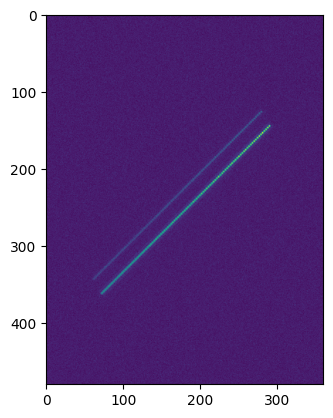

In [263]:
plt.imshow(crop_im[0]);

In [229]:
4152/12

346.0

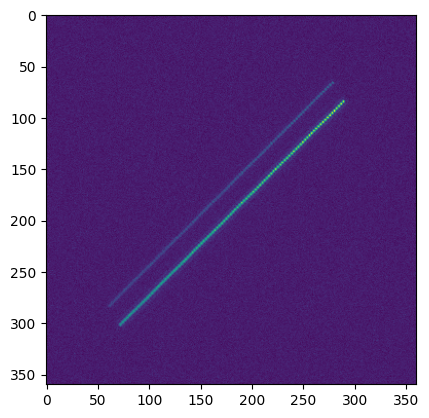

In [245]:
plt.imshow(crop_im);

In [243]:
mask[:,:,0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(360, 360))

In [236]:
output = np.tile(crop_im, (2, 1, 1)).T[mask].reshape(346*2,6)

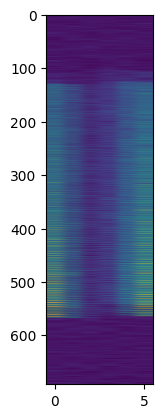

In [240]:
plt.imshow(crop, aspect=0.03);

In [219]:
np.broadcast_to(crop_im, (*crop_im.shape, 2))

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (360,360)  and requested shape (360,360,2)

In [213]:
cmask = np.max(mask,axis=2)

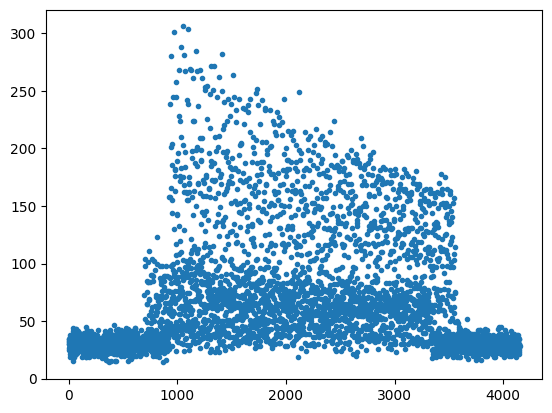

In [218]:
plt.plot(crop_im[cmask].reshape(,'.')

In [212]:
cmask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(360, 360))

In [196]:
crop_im[mask]

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [192]:
mask.shape

(360, 360, 2)

In [187]:
%%time
# for sx, sy in zip(sidelobes_x, sidelobes_y):
crop_x = crop_centre(xx, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)
crop_y = crop_centre(yy, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)

mask = (xx - yy*cot) <= width/2

CPU times: user 1.17 s, sys: 519 ms, total: 1.69 s
Wall time: 1.71 s


In [183]:
mask

array([[[False, False],
        [False, False],
        [ True, False],
        ...,
        [False, False],
        [False, False],
        [False, False]],

       [[False,  True],
        [False, False],
        [False, False],
        ...,
        [False, False],
        [False, False],
        [False, False]],

       [[False,  True],
        [False,  True],
        [False, False],
        ...,
        [False, False],
        [False, False],
        [False, False]],

       ...,

       [[False, False],
        [False, False],
        [False, False],
        ...,
        [False, False],
        [ True, False],
        [ True, False]],

       [[False, False],
        [False, False],
        [False, False],
        ...,
        [False, False],
        [False, False],
        [ True, False]],

       [[False, False],
        [False, False],
        [False, False],
        ...,
        [False,  True],
        [False, False],
        [False, False]]], shape=(3648, 3648, 2))

In [179]:
yyc

array([[[4.000e+00, 4.000e+00],
        [3.000e+00, 5.000e+00],
        [2.000e+00, 6.000e+00],
        ...,
        [3.641e+03, 3.649e+03],
        [3.642e+03, 3.650e+03],
        [3.643e+03, 3.651e+03]],

       [[5.000e+00, 3.000e+00],
        [4.000e+00, 4.000e+00],
        [3.000e+00, 5.000e+00],
        ...,
        [3.640e+03, 3.648e+03],
        [3.641e+03, 3.649e+03],
        [3.642e+03, 3.650e+03]],

       [[6.000e+00, 2.000e+00],
        [5.000e+00, 3.000e+00],
        [4.000e+00, 4.000e+00],
        ...,
        [3.639e+03, 3.647e+03],
        [3.640e+03, 3.648e+03],
        [3.641e+03, 3.649e+03]],

       ...,

       [[3.649e+03, 3.641e+03],
        [3.648e+03, 3.640e+03],
        [3.647e+03, 3.639e+03],
        ...,
        [4.000e+00, 4.000e+00],
        [3.000e+00, 5.000e+00],
        [2.000e+00, 6.000e+00]],

       [[3.650e+03, 3.642e+03],
        [3.649e+03, 3.641e+03],
        [3.648e+03, 3.640e+03],
        ...,
        [5.000e+00, 3.000e+00],
        [4.000e+00

In [137]:
yy = y - a.T

In [150]:
np.sum(yy.T[:,:,0] - (y-y_poss[0]))

np.int64(0)

In [ ]:
plt.imshow(xx, cmap='seismic', vmin = -50, vmax = 50)

In [152]:
crop_centre(xx.T, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)

array([[[-1334, -1324],
        [-1334, -1324],
        [-1334, -1324],
        ...,
        [-1334, -1324],
        [-1334, -1324],
        [-1334, -1324]],

       [[-1333, -1323],
        [-1333, -1323],
        [-1333, -1323],
        ...,
        [-1333, -1323],
        [-1333, -1323],
        [-1333, -1323]],

       [[-1332, -1322],
        [-1332, -1322],
        [-1332, -1322],
        ...,
        [-1332, -1322],
        [-1332, -1322],
        [-1332, -1322]],

       ...,

       [[ -977,  -967],
        [ -977,  -967],
        [ -977,  -967],
        ...,
        [ -977,  -967],
        [ -977,  -967],
        [ -977,  -967]],

       [[ -976,  -966],
        [ -976,  -966],
        [ -976,  -966],
        ...,
        [ -976,  -966],
        [ -976,  -966],
        [ -976,  -966]],

       [[ -975,  -965],
        [ -975,  -965],
        [ -975,  -965],
        ...,
        [ -975,  -965],
        [ -975,  -965],
        [ -975,  -965]]], shape=(360, 360, 2))

In [125]:
y - 

ValueError: operands could not be broadcast together with shapes (3648,3648) (1,1,2) 

In [75]:

y0 = y - y_poss[0]
y1 = y - y_poss[1]

In [115]:
angles_radians

array([0.78539816, 2.35619449])

In [70]:
sidelobes_y

array([ 1149,  1149, -1149, -1149])

In [269]:
sidelobes_x

array([ 1149, -1149,  1149, -1149,  1149, -1149,  1149, -1149])

In [80]:
%%time
for sx, sy in zip(sidelobes_x, sidelobes_y):
    crop_x = crop_centre(x, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)
    crop_y = crop_centre(y, centroid_data['x'] + sx, centroid_data['y'] + sy, size = length)

CPU times: user 512 μs, sys: 52 μs, total: 564 μs
Wall time: 589 μs


In [106]:
sidelobe_image = crop_centre(raw_image, centroid_data['x'] - sidelobes_x[0], centroid_data['y'] - sidelobes_y[0], size = length)

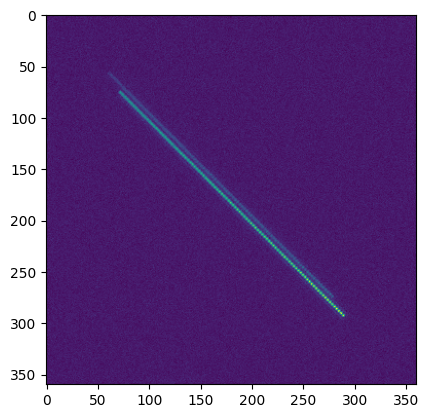

In [107]:
plt.imshow(sidelobe_image);

In [108]:
%%time
sidelobes = crop_sidelobes(sidelobe_image, x_poss, y_poss)

CPU times: user 15.9 ms, sys: 44 μs, total: 15.9 ms
Wall time: 16.6 ms


In [110]:
sidelobes

array([], shape=(0, 24), dtype=uint16)

In [84]:
x = np.arange(image.shape[1])
y = np.arange(image.shape[0])

In [89]:
x_poss

array([1829, 1819])

In [88]:
np.tan(angles_radians[0])

np.float64(0.9999999999999999)

(0.0, 3648.0)

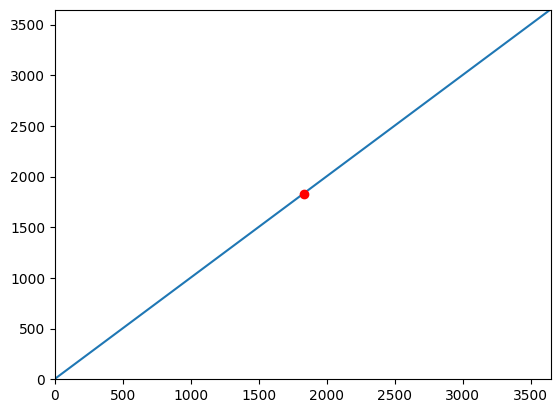

In [104]:
plt.plot(x,np.tan(np.deg2rad(45))*(x-x_poss[0])+y_poss[0])
plt.plot(x_poss[0],y_poss[0],'ro')
plt.xlim(0,image.shape[1])
plt.ylim(0,image.shape[0])

In [98]:
x0 = x - x_poss[0]
x1 = x - x_poss[1]
y0 = y - y_poss[0]
y1 = y - y_poss[1]

In [70]:
x_poss

array([2741, 2731])

In [99]:
xx = np.sqrt(np.abs(x0*x1))
yy = np.sqrt(np.abs(y0*y1))

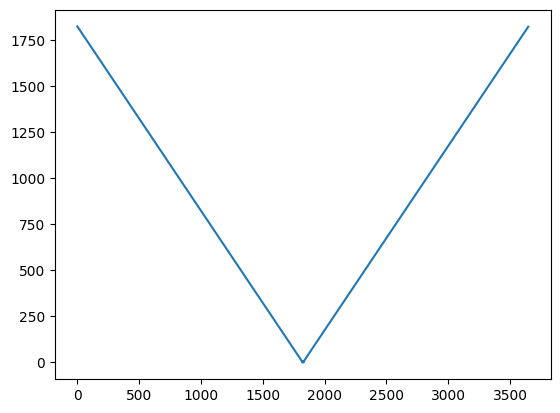

In [89]:
plt.plot(xx[0])

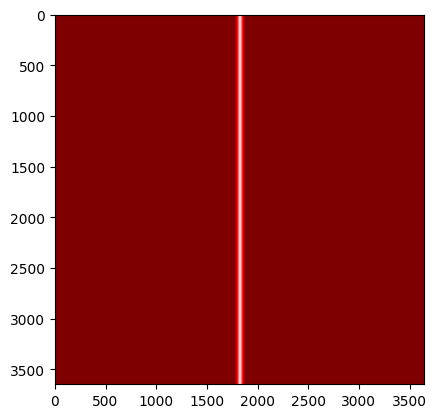

In [97]:
plt.imshow(xx, cmap='seismic', vmin = -50, vmax = 50)
# plt.xlim(1800,1850)
# plt.ylim(0,50);

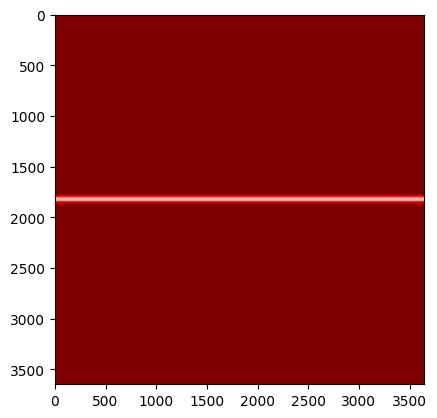

In [100]:
plt.imshow(yy, cmap='seismic', vmin = -50, vmax = 50)

In [105]:
angles_radians

[np.float64(0.7853981633974483), np.float64(2.356194490192345)]

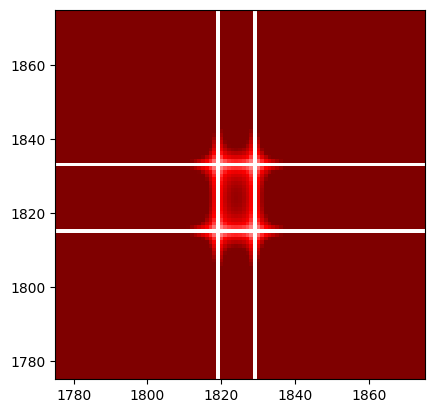

In [112]:
plt.imshow(xx*yy, cmap='seismic', vmin = -50, vmax = 50)
plt.xlim(1775,1875)
plt.ylim(1775,1875);

In [120]:
angle = angles_radians[0]
tan_angle = np.tan(angle)
cot_angle = 1/np.tan(angle)
sidelobe_x = np.abs(SIDELOBE_OFFSET * np.cos(angle))
sidelobe_y = np.abs(SIDELOBE_OFFSET * np.sin(angle))

In [145]:
tan_angles = np.tan(angles_radians)
cot_angles = 1/tan_angles

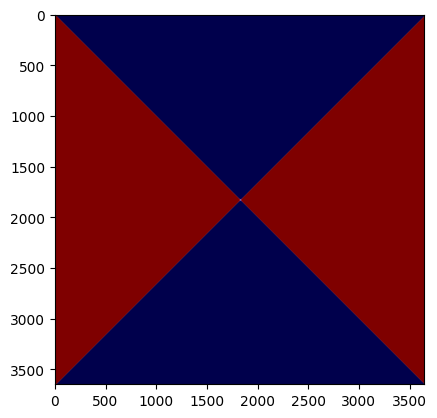

In [155]:
plt.imshow((x0-y0*cot_angles[0])*(x0-y0*cot_angles[1]), cmap='seismic', vmin=-50, vmax = 50)
# plt.xlim(1775,1875)
# plt.ylim(1775,1875);

3.0

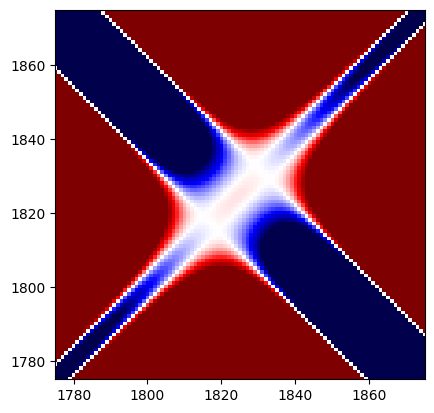

In [178]:
plt.imshow((x0-y0*cot_angles[0])*(x1-y1*cot_angles[0])*(x0-y0*cot_angles[1])*(x1-y1*cot_angles[1]), cmap='seismic', vmin=-(3**10), vmax = 3**10)
plt.xlim(1775,1875)
plt.ylim(1775,1875);

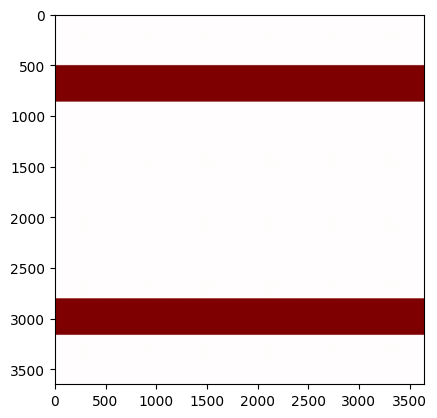

In [202]:
plt.imshow(np.abs(np.abs(y0)-sidelobe_y) <= length/2, cmap='seismic', vmin=-1, vmax = 1);

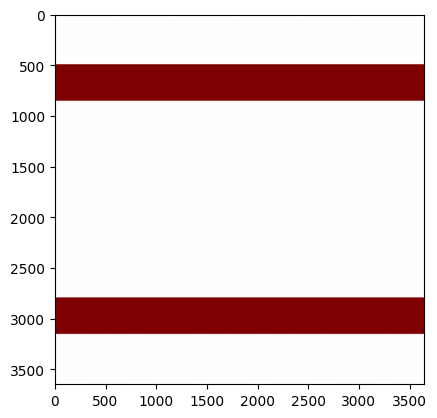

In [201]:
plt.imshow(np.abs(yy-sidelobe_y) <= length/2, cmap='seismic', vmin=-1, vmax = 1);

In [203]:
l1 = np.abs(np.abs(y0)-sidelobe_y) <= length/2
l2 = np.abs(yy-sidelobe_y) <= length/2

(400.0, 1000.0)

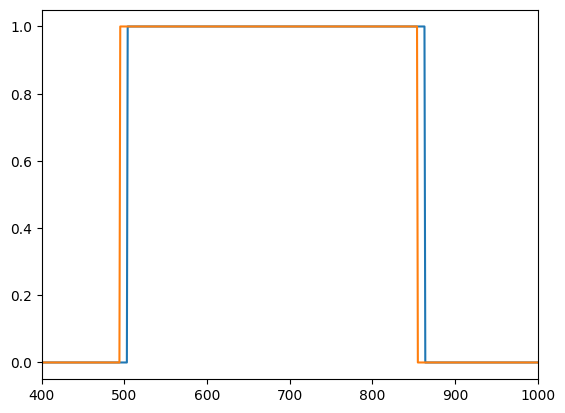

In [206]:
plt.plot(l1[:,0])
plt.plot(l2[:,0])
plt.xlim(400,1000)

(2700.0, 3300.0)

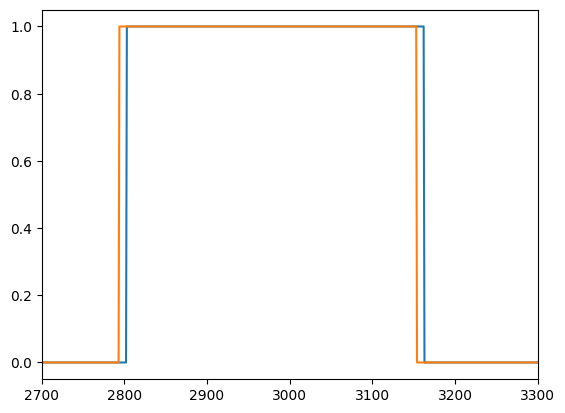

In [208]:
plt.plot(l1[:,0])
plt.plot(l2[:,0])
plt.xlim(2700,3300)

In [192]:
sidelobe_y

np.float64(1149.0485194281396)

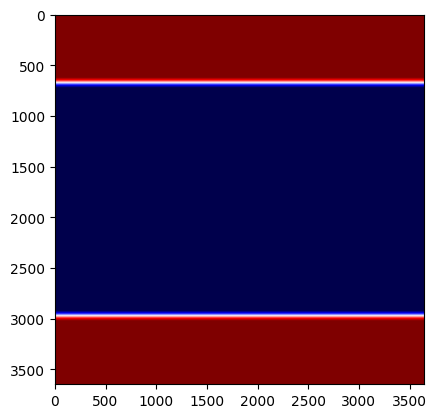

In [190]:
plt.imshow(yy - sidelobe_y, cmap='seismic', vmin=-50, vmax = 50);
# plt.xlim(1775,1875)
# plt.ylim(1775,1875);

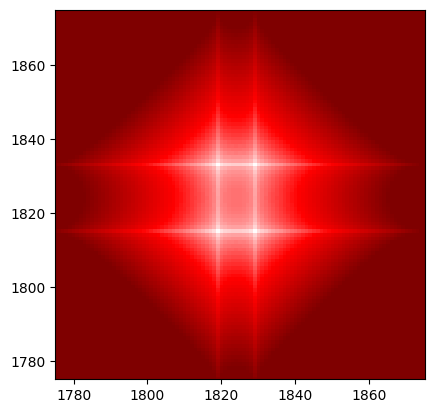

In [186]:
plt.imshow(np.abs((xx-yy*cot_angles[1])), cmap='seismic', vmin=-50, vmax = 50)
plt.xlim(1775,1875)
plt.ylim(1775,1875);

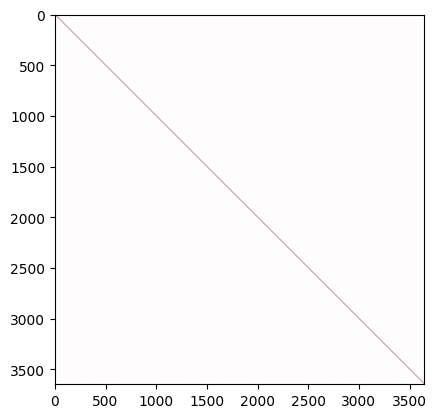

In [139]:
plt.imshow((np.abs(x0 - y0*cot_angle) <= width/2), cmap='seismic', vmin = -1, vmax = 1);
# plt.xlim(1775,1875)
# plt.ylim(1775,1875);

In [127]:
length/2

180.0

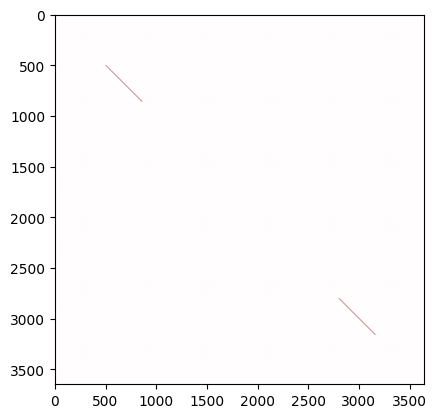

In [141]:
plt.imshow(((np.abs(np.abs(y0)-sidelobe_y)) <= length/2) * (np.abs(x0 - y0*cot_angle) <= width/2), cmap='seismic', vmin=-1, vmax=1);

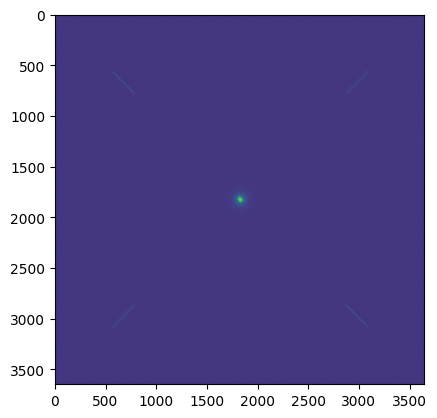

In [125]:
plt.imshow(image**0.1);

In [141]:
%%time

y1, x1 = np.indices(image.shape)

sidelobes_x = np.abs(SIDELOBE_OFFSET * np.cos(angles_radians))
sidelobes_y = np.abs(SIDELOBE_OFFSET * np.sin(angles_radians))
tan_angles = np.tan(angles_radians)
cot_angles = 1/tan_angles

for x_pos, y_pos in zip(x_poss, y_poss):
    
    y = y1 - y_pos
    x = x1 - x_pos

    for angle, sidelobe_x, sidelobe_y, tan_angle, cot_angle in zip(angles_radians, sidelobes_x, sidelobes_y, tan_angles, cot_angles):
        # sidelobe_x = np.abs(SIDELOBE_OFFSET * np.cos(angle))
        # sidelobe_y = np.abs(SIDELOBE_OFFSET * np.sin(angle))

        # tan_angle = np.tan(angle)
        # cot_angle = 1/tan_angle
        
        if np.abs(angle-np.pi/2) <= np.pi/4:
            time_0 = datetime.now()
            y_scaled = y * cot_angle
            abs_y = np.abs(y)
            abs_diff_x = np.abs(x-y_scaled)
            abs_diff_y = np.abs(abs_y - sidelobe_y)
            mask = (abs_diff_x <= width/2) & (abs_diff_y <= length/2)
            time_1 = datetime.now()
            print(str(time_1-time_0))
        else:
            time_0 = datetime.now()
            mask = (np.abs(y - x * tan_angle) <= width/2) & (np.abs(np.abs(x)-sidelobe_x) <= length/2)
            time_1 = datetime.now()
            print(str(time_1-time_0))
        output.append(image[mask].reshape((image[mask].shape[0]//width,width)))

0:00:00.295042
0:00:00.321672
0:00:00.277687
0:00:00.293012
CPU times: user 801 ms, sys: 613 ms, total: 1.41 s
Wall time: 1.43 s


array([[-1761, -1761, -1761, ..., -1761, -1761, -1761],
       [-1760, -1760, -1760, ..., -1760, -1760, -1760],
       [-1759, -1759, -1759, ..., -1759, -1759, -1759],
       ...,
       [ 1884,  1884,  1884, ...,  1884,  1884,  1884],
       [ 1885,  1885,  1885, ...,  1885,  1885,  1885],
       [ 1886,  1886,  1886, ...,  1886,  1886,  1886]],
      shape=(3648, 3648))

In [133]:
np.abs(SIDELOBE_OFFSET * np.cos(angles_radians))

array([1044.52986574, 1244.82222007])

In [134]:
tan_angles = np.tan(angles_radians)

In [142]:
tan_angles

array([ 1.19175359, -0.83909963])

In [143]:
cot_angles

array([ 0.83909963, -1.19175359])

In [144]:
s

array([-0.83909963,  1.19175359])

In [135]:
cot_angles = 1/tan_angles

In [120]:
angles_radians

[np.float64(0.6981317007977318), np.float64(2.2689280275926285)]

In [38]:
y, x = np.indices(image.shape)

In [94]:
y.dtype

dtype('int64')

In [95]:
x.dtype

dtype('int64')

In [37]:
x_poss.dtype

dtype('float64')

In [19]:
x.shape

(3648, 3648)

In [20]:
y.shape

(3648, 3648)

In [98]:
angles_radians

[np.float64(0.7853981633974483), np.float64(2.356194490192345)]

In [34]:
type(length)

int

In [23]:
sidelobe_x

np.float64(1149.0485194281396)

In [24]:
sidelobe_y

np.float64(1149.0485194281398)

In [6]:
sidelobes

array([[   0, 4093,    0, ..., 4093, 4093, 4093],
       [   0, 4093,    0, ..., 4093,    0, 4093],
       [   0, 4093,    0, ..., 4093, 4093, 4093],
       ...,
       [4093, 4093, 4093, ...,    0, 4093,    0],
       [4093,    0, 4093, ...,    0, 4093,    0],
       [4093, 4093, 4093, ...,    0, 4093,    0]],
      shape=(720, 24), dtype=uint16)

In [7]:
header

{'SEQNUM': 0,
 'CAMTIME': 6784349134256,
 'COMTIME': '2025-04-01 13:56:44.365604',
 'EXPOSURE': 46.0,
 'PXLFMT': 'Mono16',
 'XOFF': 912,
 'YOFF': 0,
 'XPAD': 0,
 'YPAD': 0}

In [8]:
# Create xarray Dataset
core_array = xr.DataArray(core, dims=("y", "x"))
sidelobe_array = xr.DataArray(sidelobes, dims=("y1", "x1"))

dataset = xr.Dataset({
    "core": core_array,
    "sidelobes": sidelobe_array
})


In [9]:
core_array

<xarray.DataArray (y: 128, x: 128)> Size: 33kB
array([[   0,    0,    0, ...,    0, 4093,    0],
       [   0, 4093,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0, 4093,    0],
       ...,
       [   0, 4093,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0, 4093,    0],
       [   0, 4093,    0, ...,    0,    0,    0]],
      shape=(128, 128), dtype=uint16)
Dimensions without coordinates: y, x

In [10]:
sidelobe_array

<xarray.DataArray (y1: 720, x1: 24)> Size: 35kB
array([[   0, 4093,    0, ..., 4093, 4093, 4093],
       [   0, 4093,    0, ..., 4093,    0, 4093],
       [   0, 4093,    0, ..., 4093, 4093, 4093],
       ...,
       [4093, 4093, 4093, ...,    0, 4093,    0],
       [4093,    0, 4093, ...,    0, 4093,    0],
       [4093, 4093, 4093, ...,    0, 4093,    0]],
      shape=(720, 24), dtype=uint16)
Dimensions without coordinates: y1, x1

In [11]:
dataset

<xarray.Dataset> Size: 67kB
Dimensions:    (y: 128, x: 128, y1: 720, x1: 24)
Dimensions without coordinates: y, x, y1, x1
Data variables:
    core       (y, x) uint16 33kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    sidelobes  (y1, x1) uint16 35kB 0 4093 0 4093 0 4093 ... 0 4093 0 4093 0

In [12]:
# Convert CAMTIME to a string to avoid truncation/error when creating netCDF file
header["CAMTIME"] = str(header["CAMTIME"])

# Add position information to header
header["CENTR_X"] = np.round(centroid_data['x'])
header["CENTR_Y"] = np.round(centroid_data['y'])
header["STAR_1_X"] = x_poss[0]
header["STAR_1_Y"] = y_poss[0]
header["STAR_2_X"] = x_poss[1]
header["STAR_2_Y"] = y_poss[1]

dataset.attrs = header

In [13]:
dataset

<xarray.Dataset> Size: 67kB
Dimensions:    (y: 128, x: 128, y1: 720, x1: 24)
Dimensions without coordinates: y, x, y1, x1
Data variables:
    core       (y, x) uint16 33kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    sidelobes  (y1, x1) uint16 35kB 0 4093 0 4093 0 4093 ... 0 4093 0 4093 0
Attributes: (12/15)
    SEQNUM:    0
    CAMTIME:   6784349134256
    COMTIME:   2025-04-01 13:56:44.365604
    EXPOSURE:  46.0
    PXLFMT:    Mono16
    XOFF:      912
    ...        ...
    CENTR_X:   1745.0
    CENTR_Y:   1823.0
    STAR_1_X:  1714.0
    STAR_1_Y:  1759.0
    STAR_2_X:  1714.0
    STAR_2_Y:  1761.0

In [23]:
# Set compression encoding
dataset["core"].encoding = {"zlib": True, "complevel": 9}
dataset["sidelobes"].encoding = {"zlib": True, "complevel": 9}

In [15]:
dataset

<xarray.Dataset> Size: 67kB
Dimensions:    (y: 128, x: 128, y1: 720, x1: 24)
Dimensions without coordinates: y, x, y1, x1
Data variables:
    core       (y, x) uint16 33kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    sidelobes  (y1, x1) uint16 35kB 0 4093 0 4093 0 4093 ... 0 4093 0 4093 0
Attributes: (12/15)
    SEQNUM:    0
    CAMTIME:   6784349134256
    COMTIME:   2025-04-01 13:56:44.365604
    EXPOSURE:  46.0
    PXLFMT:    Mono16
    XOFF:      912
    ...        ...
    CENTR_X:   1745.0
    CENTR_Y:   1823.0
    STAR_1_X:  1714.0
    STAR_1_Y:  1759.0
    STAR_2_X:  1714.0
    STAR_2_Y:  1761.0

In [16]:
dataset["core"].encoding

{'zlib': True, 'complevel': 9, 'chunksizes': (32, 32)}

In [17]:
dataset["sidelobes"].encoding

{'zlib': True, 'complevel': 9, 'chunksizes': (30, 6)}

In [18]:
core_array.nbytes + sidelobe_array.nbytes

67328

In [19]:
dataset.nbytes

67328

In [25]:
dataset.to_netcdf("output.nc")

In [26]:
reload = xr.open_dataset("output.nc")

In [29]:
reload["core"]

<xarray.DataArray 'core' (y: 128, x: 128)> Size: 33kB
[16384 values with dtype=uint16]
Dimensions without coordinates: y, x

In [11]:
data = xr.open_dataset("/home/toliman-dev/toliman/imageservice/imageservice/images/compressed/frame_proc_22540362524944.nc")

In [5]:
filepath = "/home/toliman-dev/toliman/imageservice/imageservice/images/compressed/frame_proc_22540362524944.nc"

In [8]:
with xr.open_dataset(filepath) as data:
    comtime = datetime.strptime(data.COMTIME, '%Y-%m-%d %H:%M:%S.%f')
    camtime = int(data.CAMTIME)

In [17]:
data

<xarray.Dataset> Size: 66kB
Dimensions:    (y: 128, x: 128, dim_0: 2748, dim_1: 6)
Dimensions without coordinates: y, x, dim_0, dim_1
Data variables:
    core       (y, x) uint16 33kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    sidelobes  (dim_0, dim_1) uint16 33kB 0 0 0 0 0 0 ... 0 4093 4093 4093 4093
Attributes: (12/15)
    SEQNUM:    0
    CAMTIME:   22540362524944
    COMTIME:   2025-04-08 15:55:43.682742
    EXPOSURE:  46.0
    PXLFMT:    Mono16
    XOFF:      912
    ...        ...
    CENTR_X:   1745.0
    CENTR_Y:   1823.0
    STAR_1_X:  1714.0
    STAR_1_Y:  1759.0
    STAR_2_X:  1714.0
    STAR_2_Y:  1761.0

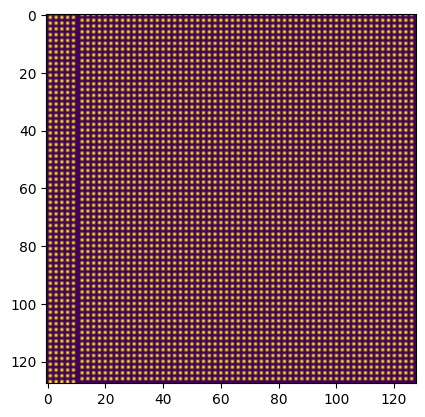

In [15]:
plt.imshow(data.core);

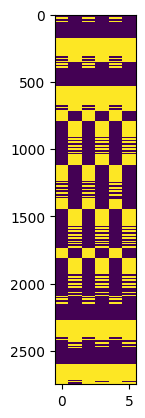

In [16]:
plt.imshow(data.sidelobes, aspect=0.01, interpolation='nearest')

In [6]:
data.COMTIME

'2025-04-08 15:55:43.682742'

In [84]:
dataset.to_netcdf("output.nc")

ModuleNotFoundError: No module named 'netCDF4'